# Quantifying Orchard Resilience

Visualize sm anomalies to start with

Measure vegetation response during and after events:

Resistance = How little the NDVI dropped during stress.

Recovery = How fast NDVI bounced back after stress.

Persistence = How stable the NDVI stays over multiple years.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

# to pick it up fast where you left
sm_df = pd.read_csv(os.path.join('Data/soil_moisture','Soil_moisture_all.csv'), index_col=0, header=0)
sm_df.index = pd.to_datetime(sm_df.index)

print(sm_df.head())

                  sm  DOY  rolling_mean    sm_DOY  sm anomaly
time_bnds                                                    
1980-01-01       NaN    1           NaN  0.415186         NaN
1980-01-02       NaN    2           NaN  0.405549         NaN
1980-01-03  0.334001    3      0.334001  0.387955   -0.053953
1980-01-04       NaN    4      0.334001  0.395356   -0.061354
1980-01-05       NaN    5      0.334001  0.402172   -0.068171


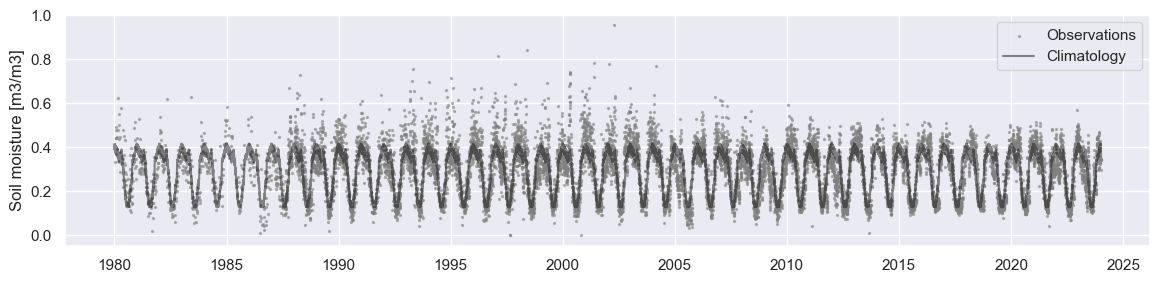

In [3]:
sns.set_theme()

fig, ax = plt.subplots(figsize=(14, 3))

plt.scatter(sm_df['sm'].index, sm_df['sm'].values, color='gray', s=2, alpha=0.5, label='Observations') 
plt.plot(sm_df['sm_DOY'].index, sm_df['sm_DOY'].values, color='k', alpha=0.5, label='Climatology')

plt.ylabel('Soil moisture [m3/m3]')
plt.legend(loc='upper right')
plt.savefig('soilmoistureALL.png', dpi=500)

plt.show()

C:\Users\ici-1\AppData\Local\Temp\ipykernel_2724\1604692163.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('bwr_r')  # blue-white-red


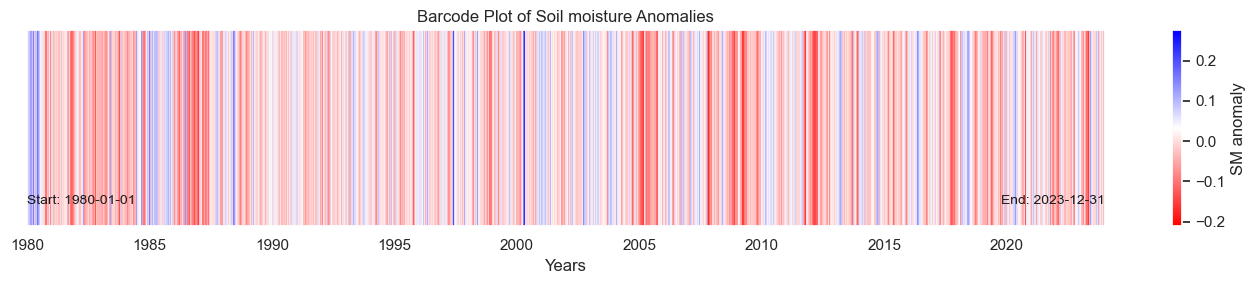

In [4]:
# Create a beautfiul plot with the downloaded data (heatmap?)
# Inspiration: https://showyourstripes.info/c/europe/portugal/lisbon
# How do I want to visualize this?

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm


# Prepare color mapping: red (-), white (0), blue (+)
norm = Normalize(vmin=sm_df['sm anomaly'].min(), vmax=sm_df['sm anomaly'].max())
cmap = cm.get_cmap('bwr_r')  # blue-white-red


fig, ax = plt.subplots(figsize=(14, 3))

# Create barcode plot
for i in sm_df.index:
    score = sm_df['sm anomaly'][i]
    ax.axvline(x=i, color=cmap(norm(score)), linewidth=1)


# Add start and end markers
start_label = f"Start: {sm_df.index[0].date()}"
end_label = f"End: {sm_df.index[-1].date()}"
ax.text(sm_df.index[0], 0.1, start_label, ha='left', va='bottom', fontsize=10, color='k', transform=ax.get_xaxis_transform())
ax.text(sm_df.index[-1], 0.1, end_label, ha='right', va='bottom', fontsize=10, color='k', transform=ax.get_xaxis_transform())


plt.title('Barcode Plot of Soil moisture Anomalies')
plt.yticks([])
plt.xlabel('Years')
plt.xlim(sm_df.index[0], sm_df.index[-1])


# Add colorbar with mappable
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # needed for colorbar
fig.colorbar(sm, ax=ax, orientation='vertical', label='SM anomaly')

plt.tight_layout()
plt.show()


In [5]:
# Filter dates for March to September
df_filtered = sm_df[sm_df.index.month.isin([3, 4, 5, 6, 7, 8, 9])]

# days of positive and negative anomalies and changes through years in growing season
negative_anomalies = df_filtered[(df_filtered['sm anomaly'] < 0)]
positive_anomalies = df_filtered[(df_filtered['sm anomaly'] > 0)]

# Count the number of days for each year with positive anomalies
positive_counts = positive_anomalies.groupby(positive_anomalies.index.year).size()

# Count the number of days for each year with negative anomalies
negative_counts = negative_anomalies.groupby(negative_anomalies.index.year).size()

print(positive_anomalies.head())

            sm  DOY  rolling_mean    sm_DOY  sm anomaly
time_bnds                                              
1980-03-01 NaN   61      0.480711  0.355352    0.125358
1980-03-02 NaN   62      0.480711  0.355644    0.125066
1980-03-03 NaN   63      0.408572  0.351542    0.057030
1980-03-04 NaN   64      0.477351  0.355633    0.121718
1980-03-05 NaN   65      0.477351  0.348972    0.128379


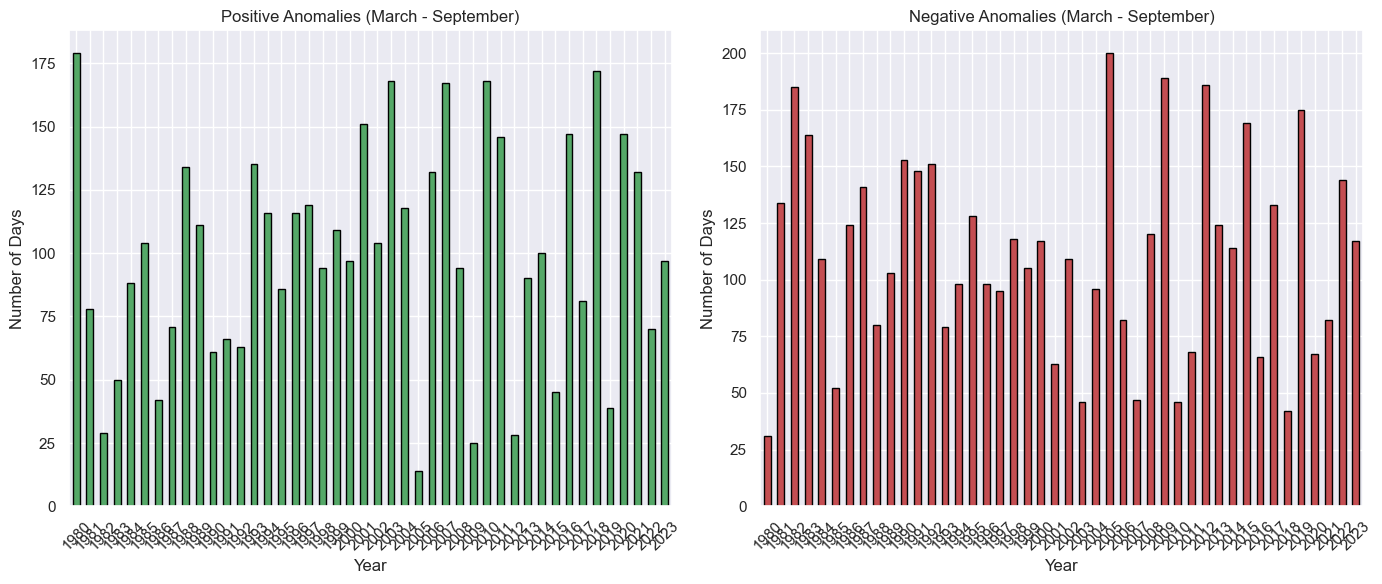

In [6]:
from scipy.stats import linregress

# Calculate summary statistics for positive anomalies
positive_mean = positive_counts.mean()
positive_std = positive_counts.std()
positive_slope, positive_intercept, positive_r_value, positive_p_value, positive_std_err = linregress(positive_counts.index, positive_counts)

# Calculate summary statistics for negative anomalies
negative_mean = negative_counts.mean()
negative_std = negative_counts.std()
negative_slope, negative_intercept, negative_r_value, negative_p_value, negative_std_err = linregress(negative_counts.index, negative_counts)

# Prepare the figure for barplots
plt.figure(figsize=(14, 6))

# Bar plot for positive anomalies
plt.subplot(1, 2, 1)
positive_counts.plot(kind='bar', color='g', edgecolor='black')
plt.title(f'Positive Anomalies (March - September)')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)

# Bar plot for negative anomalies
plt.subplot(1, 2, 2)
negative_counts.plot(kind='bar', color='r', edgecolor='black')
plt.title(f'Negative Anomalies (March - September)')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()
plt.show()


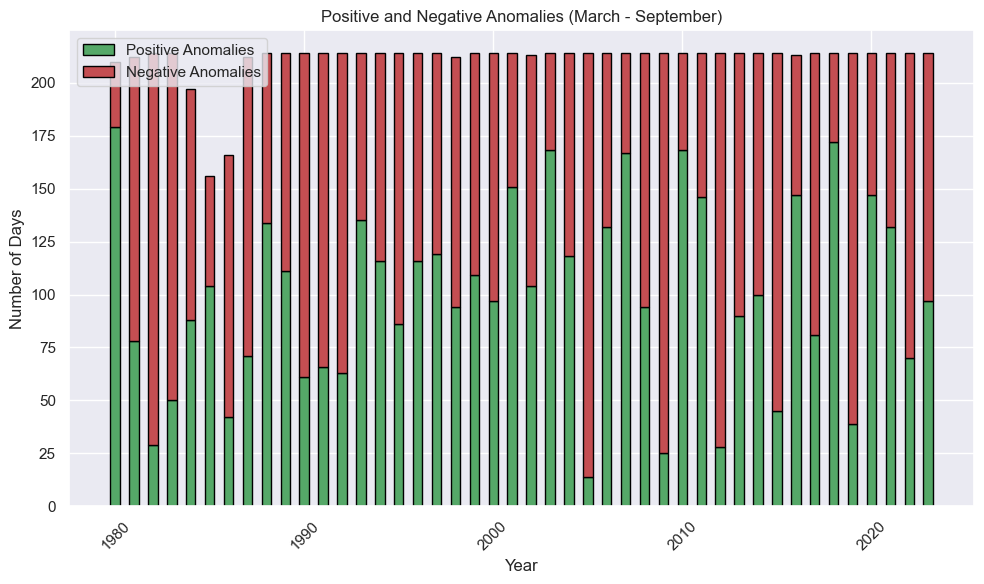

In [7]:
# Prepare the figure for the combined bar plot
plt.figure(figsize=(10, 6))

# Bar plot for both positive and negative anomalies, stacked
bar_width = 0.5  # width of the bars
plt.bar(positive_counts.index, positive_counts, width=bar_width, color='g', label='Positive Anomalies', edgecolor='black')
plt.bar(negative_counts.index, negative_counts, width=bar_width, bottom=positive_counts, color='r', label='Negative Anomalies', edgecolor='black')

# Titles and labels
plt.title(f'Positive and Negative Anomalies (March - September)')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)

# Add legend
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

#### On long term soil moisture records
Interesting to see in the above figures that there is a more erratic behavior of soil moisture in the area. Extreme drought events seem to happen more often then before. Maybe interesting to also look at occurence of consecutive days of negative anomalies (e.g. barely any rainfall for longer periods during the season).

In [8]:
last_few_years = sm_df['2023-01-01':'2023-12-31']

Text(0, 0.5, 'Soil moisture [m3/m3]')

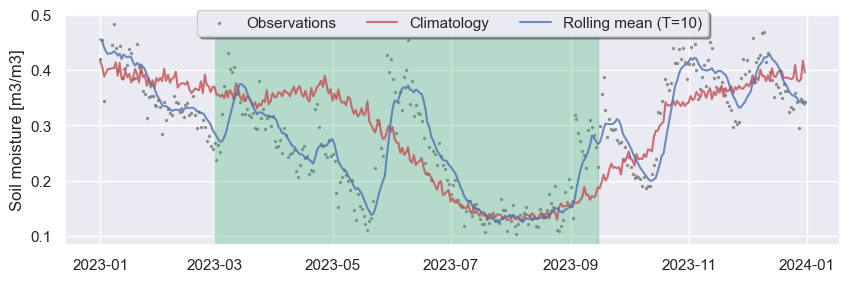

In [9]:
# last five years

sns.set_theme()

fig, ax = plt.subplots(figsize=(10, 3))

plt.scatter(last_few_years['sm'].index, last_few_years['sm'].values, color='gray', s=2, alpha=0.8, label='Observations') 
plt.plot(last_few_years['sm_DOY'].index, last_few_years['sm_DOY'].values, color='r', alpha=0.8, label='Climatology')
plt.plot(last_few_years['rolling_mean'].index, last_few_years['rolling_mean'].values, color='b', alpha=0.8, label='Rolling mean (T=10)')

# Loop through each year and color the background for March to September
for year in range(last_few_years.index.year.min(), last_few_years.index.year.max() + 1):
    start_date = pd.Timestamp(f'{year}-03-01')  # March 1st of the year
    end_date = pd.Timestamp(f'{year}-09-15')   # September 30th of the year
    ax.axvspan(start_date, end_date, color='mediumseagreen', alpha=0.3)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),
          ncol=3, fancybox=True, shadow=True)

plt.ylabel('Soil moisture [m3/m3]')
#plt.legend(loc='upper left')

1) Identify together with partners which period is vital for the almond orchards in order to correctly quantify orchard resilience
2) Difficulty to ingest NRT high resolution soil moisture data (SMAP, SMOS)

In [11]:
# Path to the folder containing your CSVs
folder_path = r'Data/regen_farms'

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

print(csv_files)

['NDVI_TimeSeries_PerFeature_Carrascalao.csv', 'NDVI_TimeSeries_PerFeature_ext.csv', 'NDVI_TimeSeries_PerFeature_ext_RU_20.csv', 'NDVI_TimeSeries_PerFeature_MonteSilveira.csv', 'NDVI_TimeSeries_PerFeature_RU_Fortes_trial.csv', 'NDWI_TimeSeries_PerFeature_Carrascalao.csv', 'NDWI_TimeSeries_PerFeature_ext.csv', 'NDWI_TimeSeries_PerFeature_ext_RU_20.csv', 'NDWI_TimeSeries_PerFeature_MonteSilveira.csv', 'NDWI_TimeSeries_PerFeature_RU_Fortes_trial.csv']


In [12]:
# Group files by location (assuming location is between the 'NDVI_TimeSeries_PerFeature_' and '.csv')
location_groups = {}

# Loop through all CSV files to group them by location name
for csv_file in csv_files:
    # Extract the location name by removing the "NDVI_TimeSeries_PerFeature_" prefix and ".csv" suffix
    if 'NDVI' in csv_file:
        location_name = csv_file.replace('NDVI_TimeSeries_PerFeature_', '').replace('.csv', '')
    elif 'NDWI' in csv_file:
        location_name = csv_file.replace('NDWI_TimeSeries_PerFeature_', '').replace('.csv', '')
    
    # Initialize a dictionary for the location if it's not already in the dictionary
    if location_name not in location_groups:
        location_groups[location_name] = {'NDVI': None, 'NDWI': None}
    
    # Assign the file to the correct type (NDVI or NDWI)
    if 'NDVI' in csv_file:
        location_groups[location_name]['NDVI'] = csv_file
    elif 'NDWI' in csv_file:
        location_groups[location_name]['NDWI'] = csv_file

location_groups

{'Carrascalao': {'NDVI': 'NDVI_TimeSeries_PerFeature_Carrascalao.csv',
  'NDWI': 'NDWI_TimeSeries_PerFeature_Carrascalao.csv'},
 'ext': {'NDVI': 'NDVI_TimeSeries_PerFeature_ext.csv',
  'NDWI': 'NDWI_TimeSeries_PerFeature_ext.csv'},
 'ext_RU_20': {'NDVI': 'NDVI_TimeSeries_PerFeature_ext_RU_20.csv',
  'NDWI': 'NDWI_TimeSeries_PerFeature_ext_RU_20.csv'},
 'MonteSilveira': {'NDVI': 'NDVI_TimeSeries_PerFeature_MonteSilveira.csv',
  'NDWI': 'NDWI_TimeSeries_PerFeature_MonteSilveira.csv'},
 'RU_Fortes_trial': {'NDVI': 'NDVI_TimeSeries_PerFeature_RU_Fortes_trial.csv',
  'NDWI': 'NDWI_TimeSeries_PerFeature_RU_Fortes_trial.csv'}}

Keep in mind - Size of the case studies:
* Carrascalao - 7.3 ha
* RU Fortes - 11 ha
* Monte Silveira - 6.5 ha

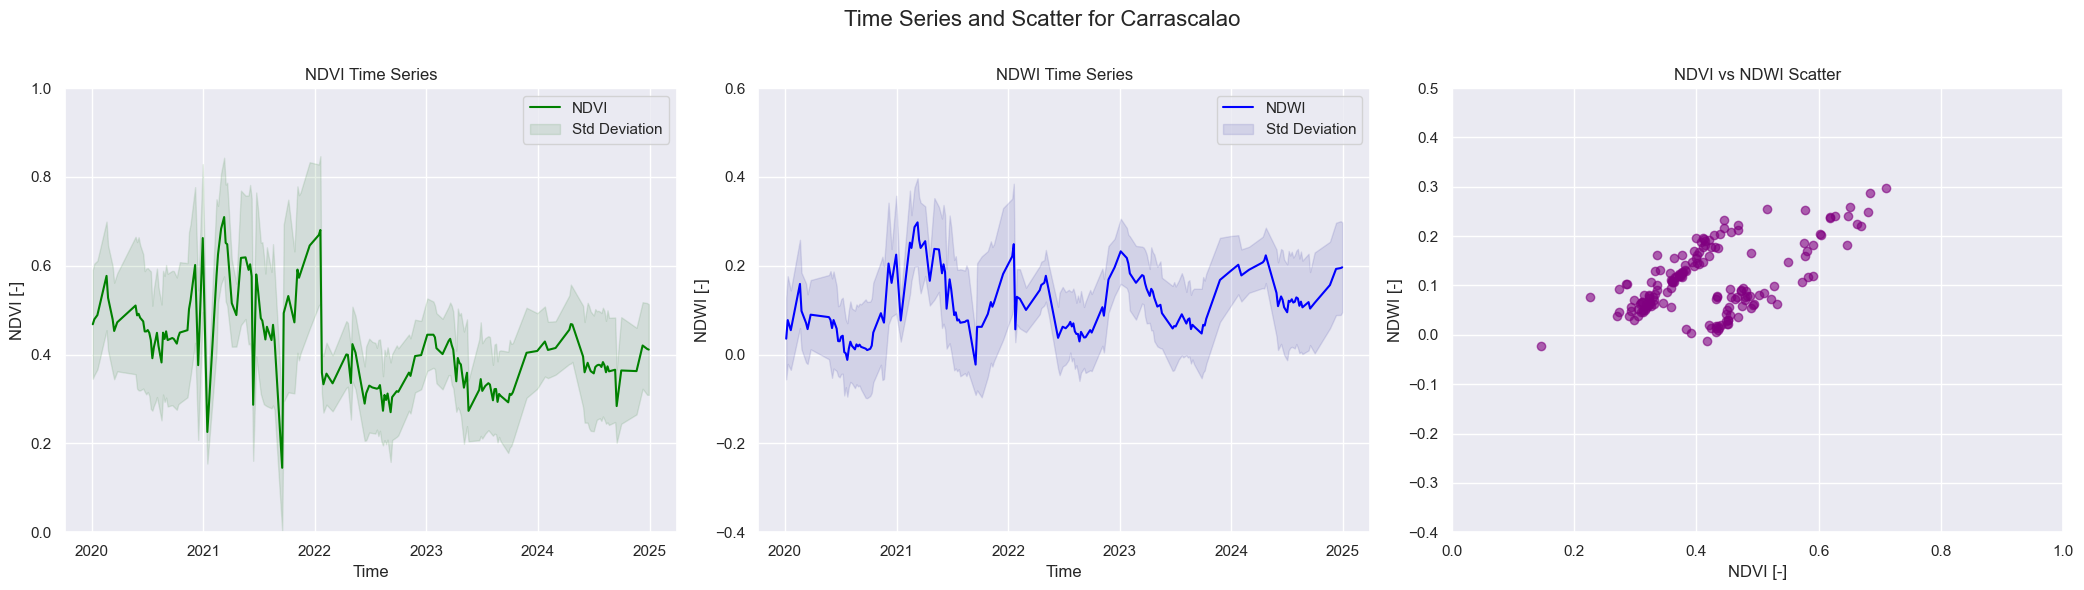

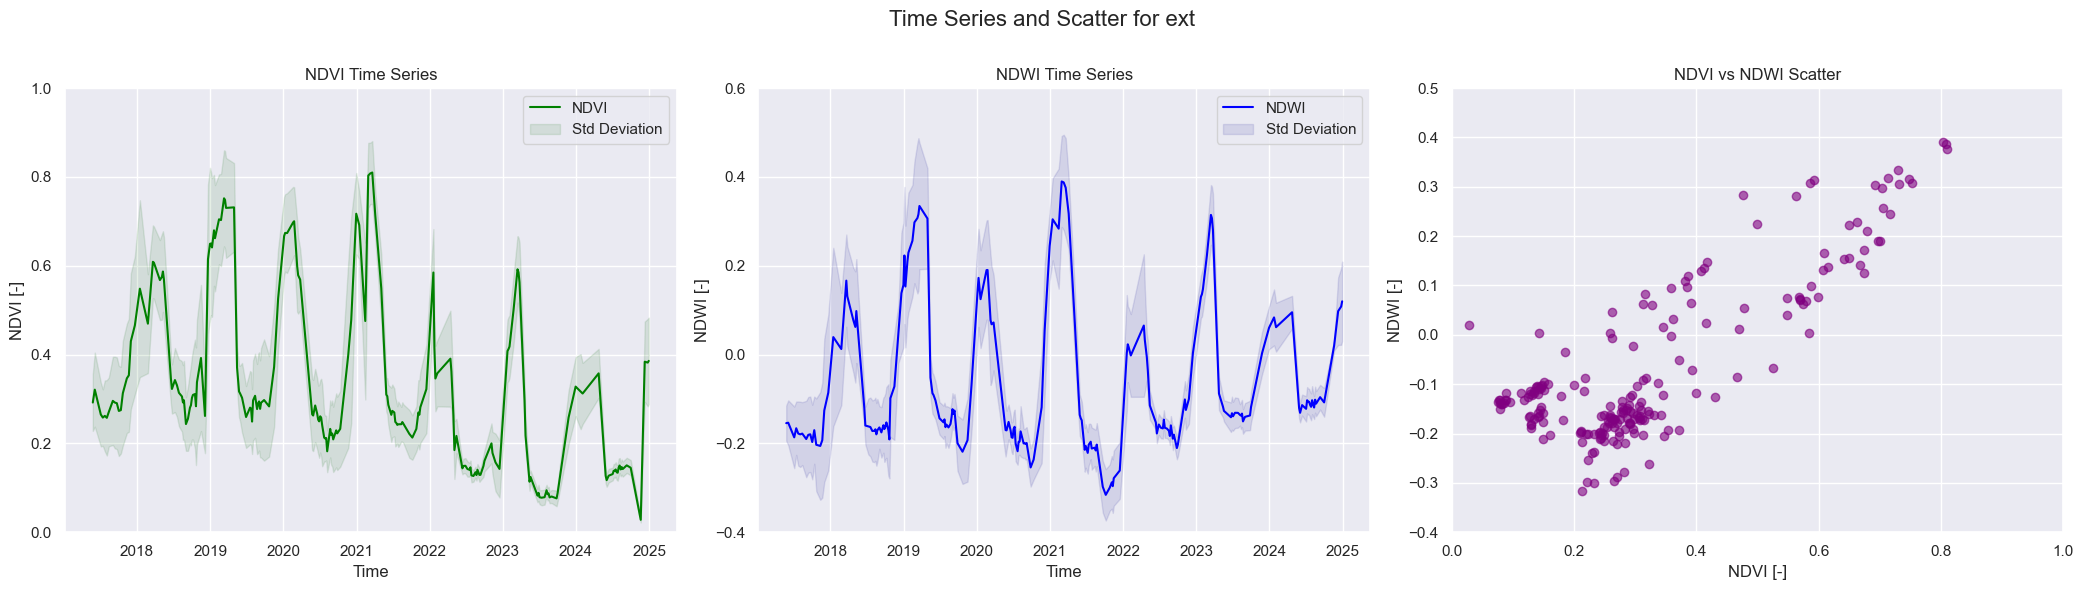

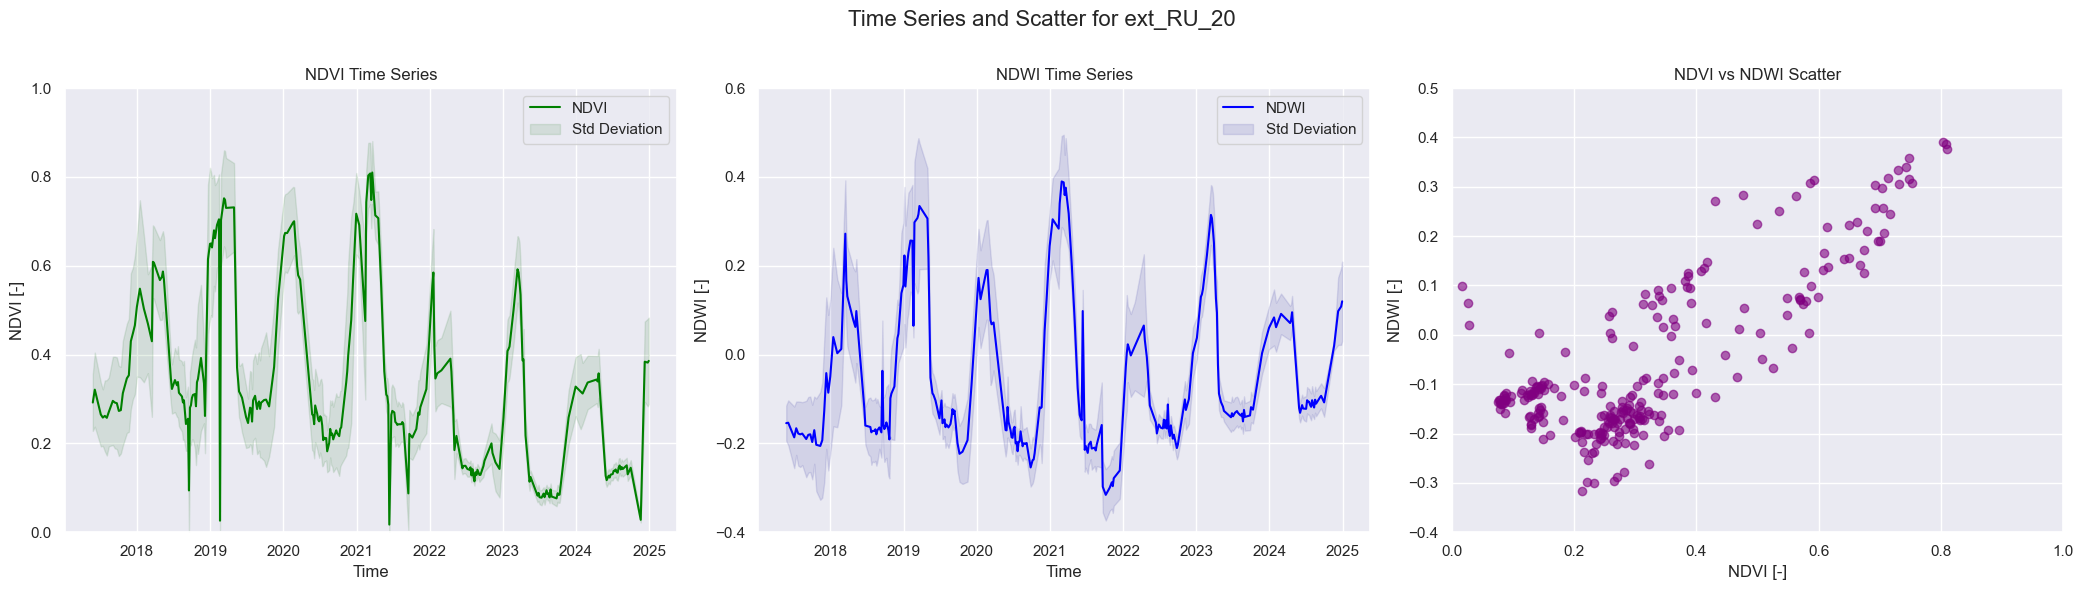

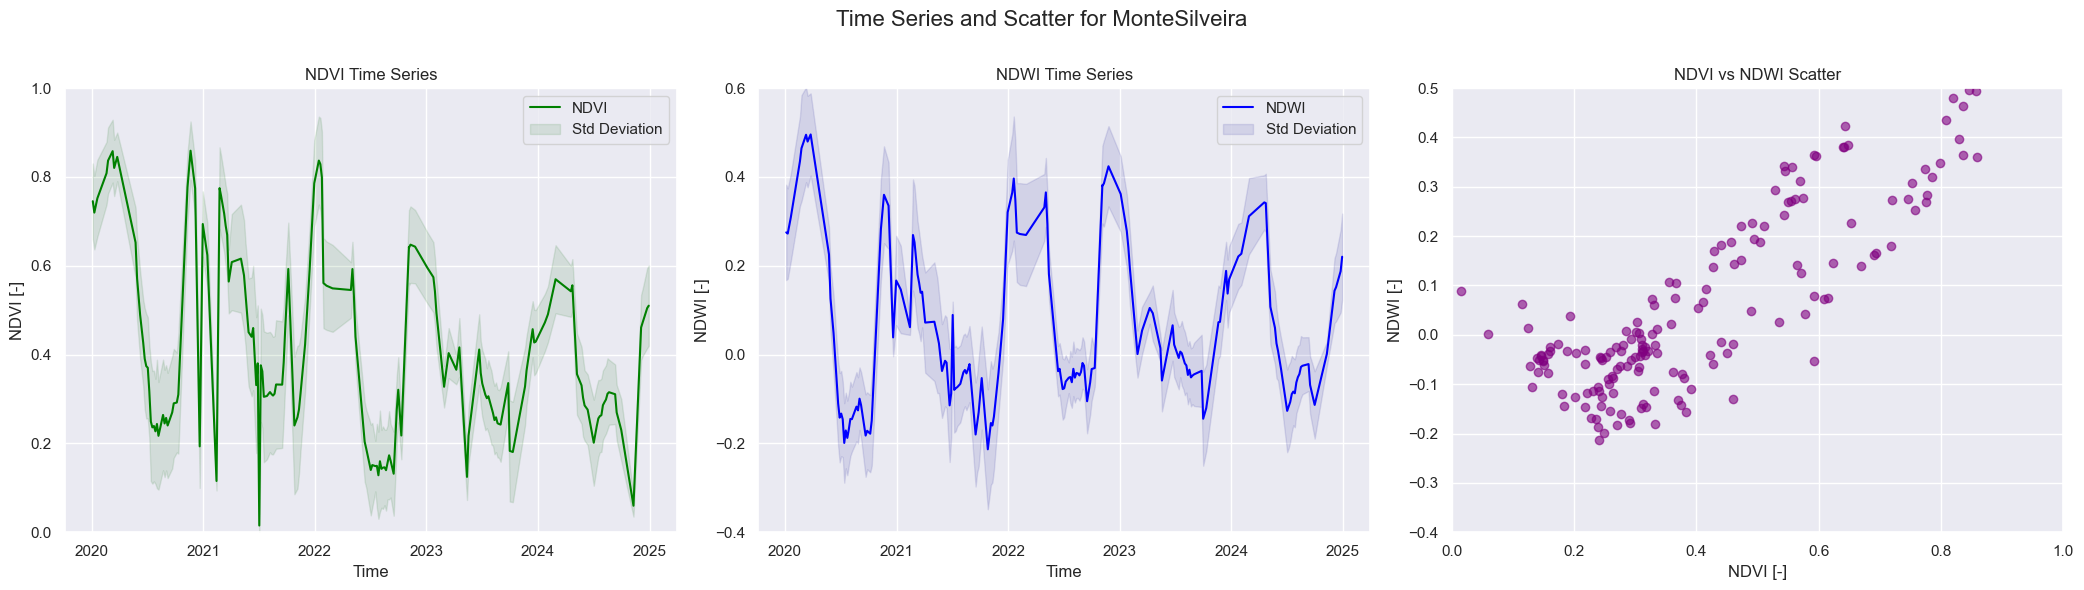

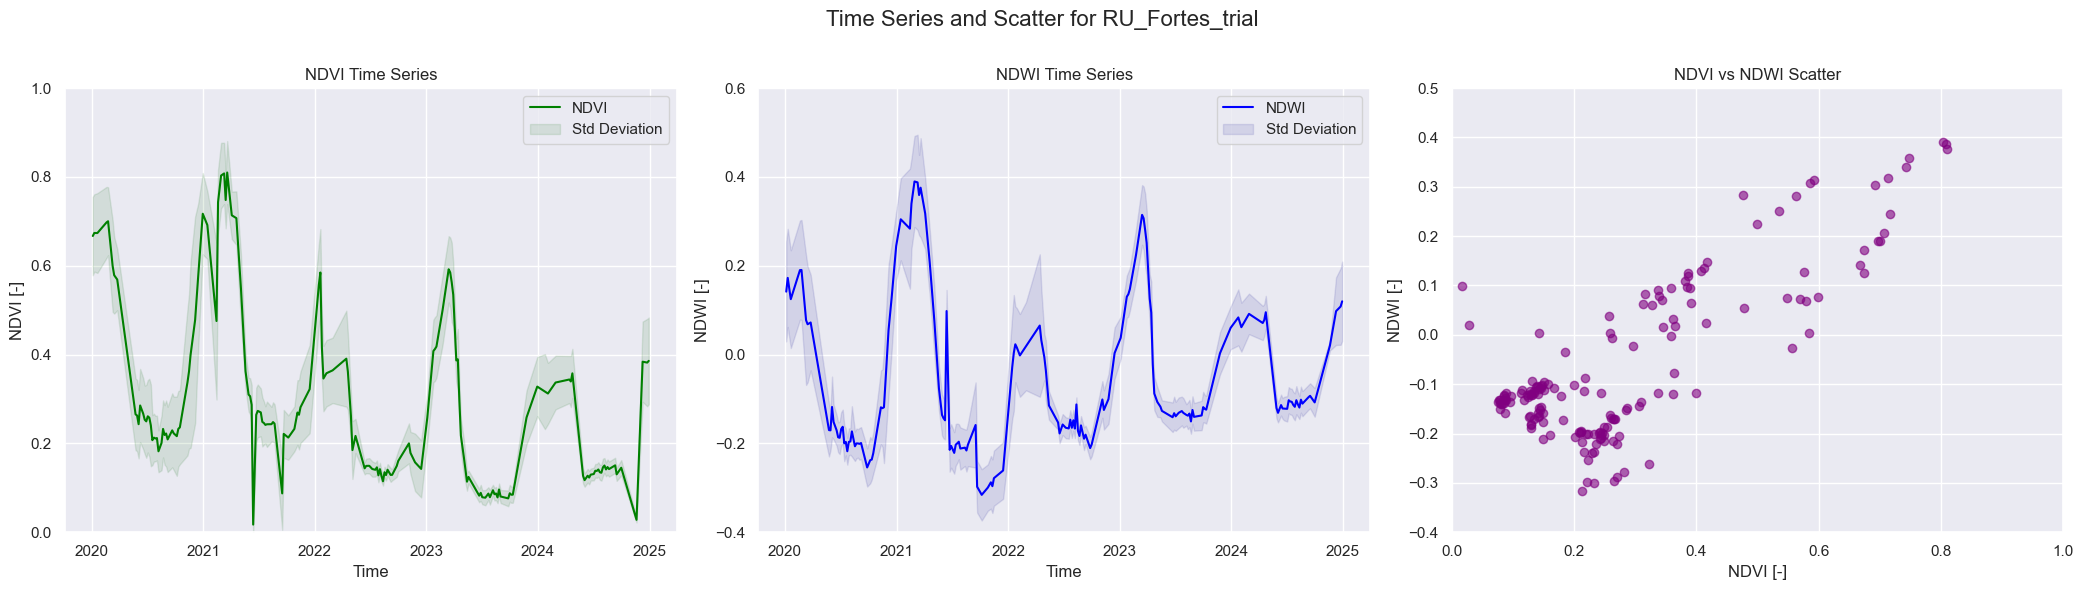

In [13]:

# Plotting time series for each location
for location, files in location_groups.items():
    # Get the full path for both NDVI and NDWI files
    ndvi_file = os.path.join(folder_path, files['NDVI'])
    ndwi_file = os.path.join(folder_path, files['NDWI'])
    
    # Load both CSVs into DataFrames
    df_ndvi = pd.read_csv(ndvi_file, index_col='date')
    df_ndwi = pd.read_csv(ndwi_file, index_col='date')
    
    # Ensure the 'time' column is in datetime format
    df_ndvi.index = pd.to_datetime(df_ndvi.index)
    df_ndwi.index = pd.to_datetime(df_ndwi.index)
    
    # Create a figure with two subplots (one for NDVI and one for NDWI)
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    fig.suptitle(f'Time Series and Scatter for {location}', fontsize=16)
    
    # Plot NDVI
    axes[0].plot(df_ndvi.index, df_ndvi['NDVI_mean'].values, label='NDVI', color='green')
    axes[0].fill_between(df_ndvi.index, df_ndvi["NDVI_mean"] - df_ndvi["NDVI_stdDev"], df_ndvi["NDVI_mean"] + df_ndvi["NDVI_stdDev"], color='darkgreen', alpha=0.1, label='Std Deviation')
    axes[0].set_title('NDVI Time Series')
    axes[0].set_xlabel('Time')
    axes[0].set_ylim(0,1)
    axes[0].set_ylabel('NDVI [-]')
    axes[0].legend()
    
    # Plot NDWI
    axes[1].plot(df_ndwi.index, df_ndwi['NDWI_mean'].values, label='NDWI', color='blue')
    axes[1].fill_between(df_ndwi.index, df_ndwi["NDWI_mean"] - df_ndwi["NDWI_stdDev"], df_ndwi["NDWI_mean"] + df_ndwi["NDWI_stdDev"], color='darkblue', alpha=0.1, label='Std Deviation')
    axes[1].set_title('NDWI Time Series')
    axes[1].set_xlabel('Time')
    axes[1].set_ylim(-0.4,0.6)
    axes[1].set_ylabel('NDWI [-]')
    axes[1].legend()

    # Scatter plot NDVI vs NDWI
    axes[2].scatter(df_ndvi['NDVI_mean'].values, df_ndwi['NDWI_mean'].values, color='purple', alpha=0.6)
    axes[2].set_title('NDVI vs NDWI Scatter')
    axes[2].set_xlabel('NDVI [-]')
    axes[2].set_xlim(0,1)
    axes[2].set_ylim(-0.4,0.5)
    axes[2].set_ylabel('NDWI [-]')
    axes[2].grid(True)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Adjust the title to avoid overlap
    plt.show()

* 2023 clearly shows drought anomaly in the soil moisture data
* NDVI Time Series are not similar to Vera Cruz → Peak around new year/beginning of year
* Carrascalao high standard deviation → why? And NDVI significantly drops after 2022: what happens? This seems to be an event
* In all NDWI going up after 2022 in lows, most prominent in RU Fortes


In [ ]:
# to pick it up fast where you left
df_trial_hist_veg = pd.read_csv(os.path.join('Data/regen_farms/','NDVI_TimeSeries_PerFeature_ext_RU_20.csv'), index_col=7, header=0)
df_trial_hist_veg.index = pd.to_datetime(df_trial_hist_veg.index)

print(df_trial_hist_veg.head())

                                                 system:index  NDVI_max  \
date                                                                      
2017-05-25  00000000000000000000_20170525T112121_20170525T...  0.489350   
2017-06-04  00000000000000000000_20170604T112121_20170604T...  0.587816   
2017-07-04  00000000000000000000_20170704T112111_20170704T...  0.495265   
2017-07-14  00000000000000000000_20170714T112111_20170714T...  0.458871   
2017-07-24  00000000000000000000_20170724T112121_20170724T...  0.516484   

            NDVI_mean  NDVI_median  NDVI_min  NDVI_pixelCount  NDVI_stdDev  \
date                                                                         
2017-05-25   0.292008     0.280225  0.153266             1194     0.063901   
2017-06-04   0.321022     0.299952  0.154159             1194     0.083409   
2017-07-04   0.265004     0.242989  0.116557             1194     0.071874   
2017-07-14   0.258112     0.239112  0.127517             1194     0.063554   
2017-0

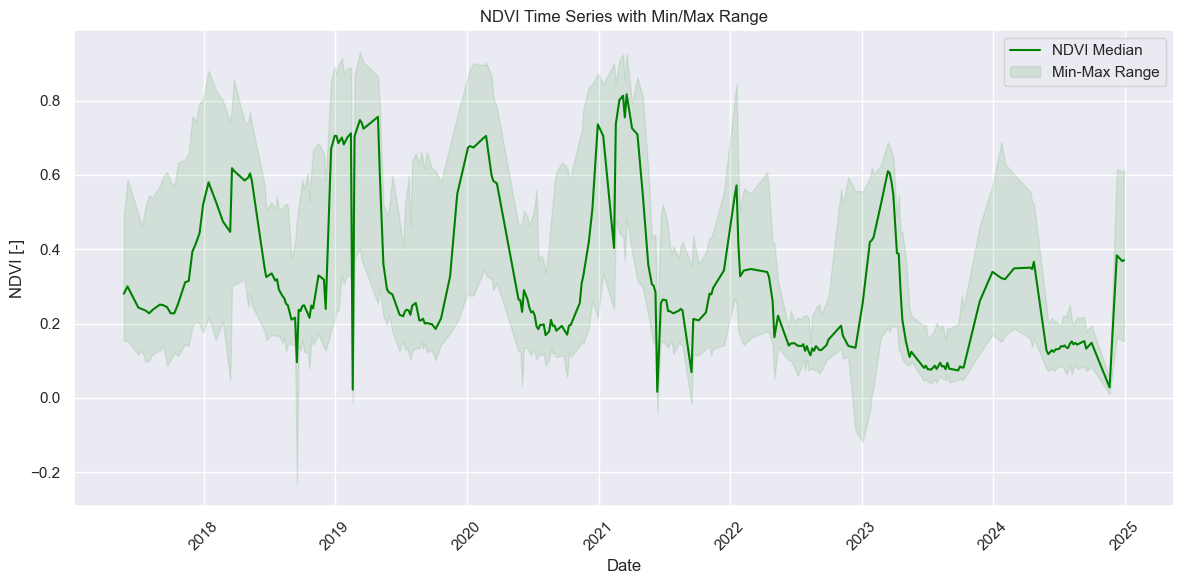

In [15]:
# === Plot NDVI time series with min/max around median ===
plt.figure(figsize=(12, 6))
plt.plot(df_trial_hist_veg.index, df_trial_hist_veg['NDVI_median'], color='green', label='NDVI Median')

# Fill between min and max
plt.fill_between(df_trial_hist_veg.index, df_trial_hist_veg['NDVI_min'], df_trial_hist_veg['NDVI_max'], color='green', alpha=0.1, label='Min-Max Range')

# Labels and legend
plt.title('NDVI Time Series with Min/Max Range')
plt.xlabel('Date')
plt.ylabel('NDVI [-]')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# === Show plot ===
plt.show()

In [28]:
df_trial_hist_veg['year'] = df_trial_hist_veg.index.year
df_trial_hist_veg['DOY'] = df_trial_hist_veg.index.dayofyear

# === Group by year and DOY ===
pivot = df_trial_hist_veg.pivot_table(index='DOY', columns='year', values='NDVI_median')

# === Compute average NDVI per DOY ===
pivot['Average'] = pivot.mean(axis=1)#.rolling(10) #, skipna=True
pivot['Rolling Average'] = pivot['Average'].rolling(10).mean()

lst_years =list(pivot.columns.values)
print(lst_years)
count = pivot.count(axis=0)
print(count)

n_observations = pd.DataFrame(data=count[:-2]) #, columns=lst_years[:-2]
n_observations 


[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 'Average', 'Rolling Average']
year
2017                19
2018                36
2019                35
2020                39
2021                33
2022                32
2023                34
2024                29
Average            122
Rolling Average    113
dtype: int64


,0
year,
2017,19
2018,36
2019,35
2020,39
2021,33
2022,32
2023,34
2024,29


19

2017
2018
2019
2020
2021
2022
2023
2024


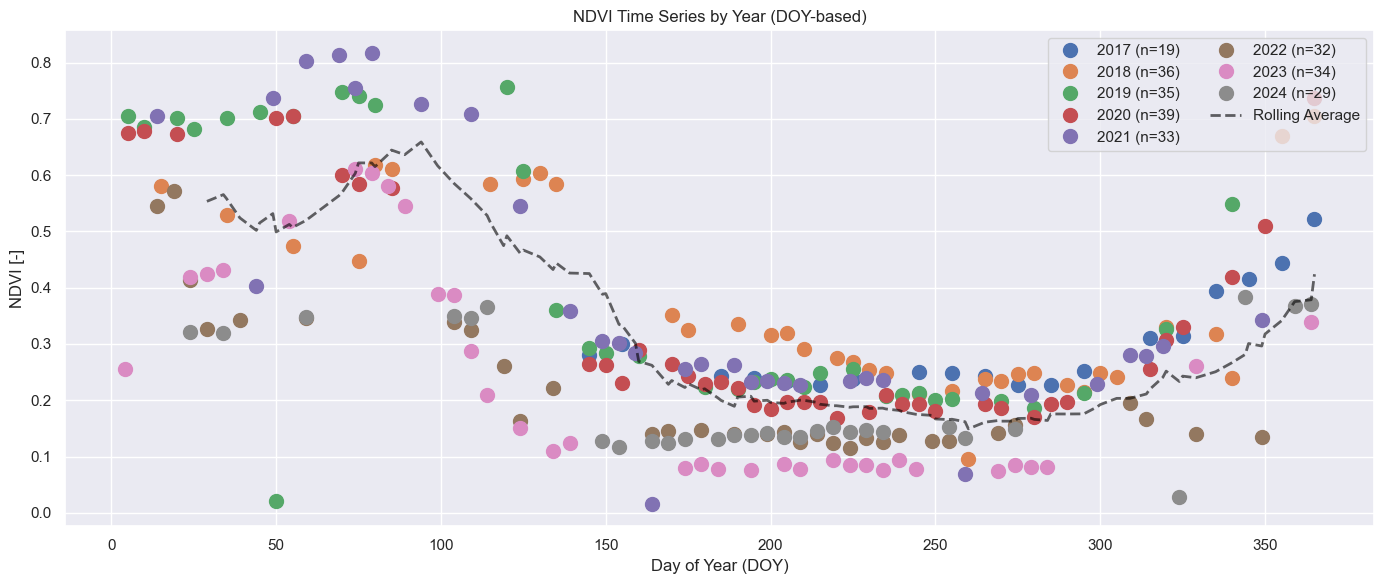

In [41]:
# === Plot ===
plt.figure(figsize=(14, 6))

# Plot each year
for year in pivot.columns[:-2]:

    print(year)
    
    label = f"{year} (n={n_observations.loc[year].item()})"
    plt.plot(pivot.index, pivot[year], ls='', marker='o', markersize=10, label=label)

# Plot average line
plt.plot(pivot.index, pivot['Rolling Average'], label='Rolling Average', color='black', alpha=0.6, linewidth=2, linestyle='--')

# === Format plot ===
plt.title('NDVI Time Series by Year (DOY-based)')
plt.xlabel('Day of Year (DOY)')
plt.ylabel('NDVI [-]')
plt.legend(loc='upper right', ncol=2)
plt.grid(True)
plt.tight_layout()

# Show plot
plt.show()


## How to continue with Quantifying Orchard Resilience?
* More analysis needed on the vegetation signal for Almond: how different varieties and management affect the signal?
* Get or create ARD NDVI and NDWI
* Check other vegetation indices for usefulness (think of NDGI, EVI; perhaps Sentinel-1 CR)
* Check other options for NRT Soil moisture (I think coarse resolution is what we need for now https://www.wri.org/aqueduct)
* Identify together with partners which period is vital for the almond orchards in order to correctly quantify orchard resilience
* Get ground data from Arbo-Innova 
* Is it possible to create a field history to benchmark? --> does this create too much noise? Or nearest neighbors? Or regional signal useful to benchmark effect vegetation on weather extremes?